# Agentic Systems - Autonomous Agents

Welcome back, Sacha! You've built a solid foundation across LLM fundamentals, evaluation, and tool use — now it's time to put it all together in something genuinely powerful.

Right now, your LLM applications are still **orc**hestrated by you* — you decide the sequence of steps, which tools to call, when to stop. **Agentic systems** change that: they give your applications the ability to **reason, plan, and act autonomously, deciding their own next steps until a task is complete.

That directly unlocks what you're building toward — a SQL agent that doesn't just answer one question, but can **navigate a financial dataset**, chain tool calls intelligently, and recover when something goes wrong. This course gives you the framework to build exactly that, reliably and at production quality. Let's get started!

With your context set, let's jump into the heart of this course: **AI Agents**.

You've already built LLM applications that call tools — but there's a meaningful leap between an app that calls a tool when told to and one that **decides for itself** what to do next, chains multiple actions together, and knows when it's done. That leap is what separates a chatbot from an agent.

In this lesson, we'll unpack exactly what makes a system agentic, how agents are structured and how they operate — and then build one from scratch using **LangGraph**. Let's dive in!

The term **"AI agent"** has gone from niche jargon to one of the hottest phrases in the industry — and the search trend here tells that story clearly. Interest was relatively flat through early 2024, then accelerated sharply, hitting peak search volume by mid-2025.

This isn't just hype cycles — it reflects a genuine shift in what people are building. The community realized that LLMs paired with tools and autonomy can tackle a much broader class of problems than simple question-answering.

Given your work in financial markets — what comes to mind when you hear **"AI agent"**?

To sharpen it a bit further: we call these systems **AI agents** — software that uses AI to pursue goals and complete tasks on behalf of users. The contrast is with **chatbots**, which primarily answer questions from their knowledge base but don't take actions to accomplish anything in the world.

Think about your SQL agent idea. A chatbot might answer _"what's the best model for predicting mortgage prepayment?"_ from training data. An agent would actually **query your financial database**, pull the relevant features, cross-reference results, and return a grounded answer — acting until the task is complete.

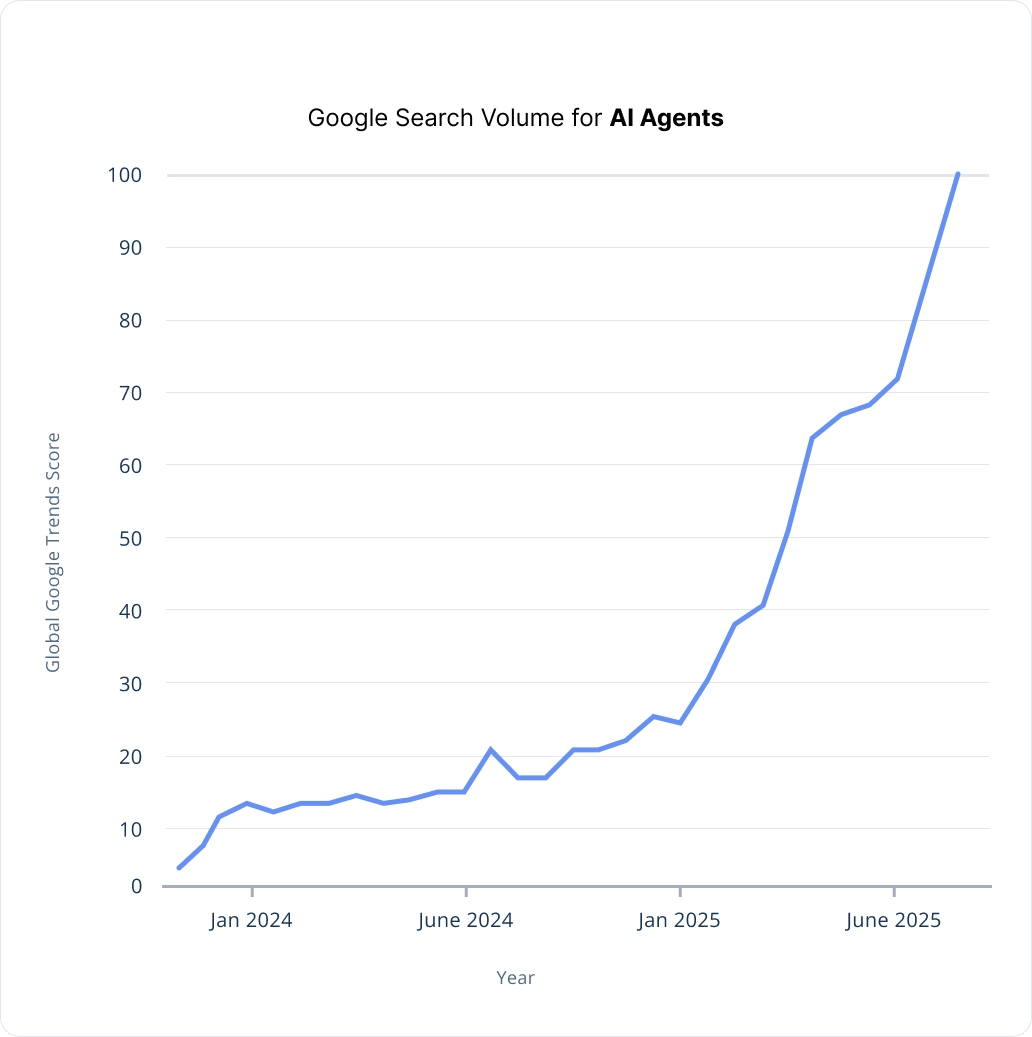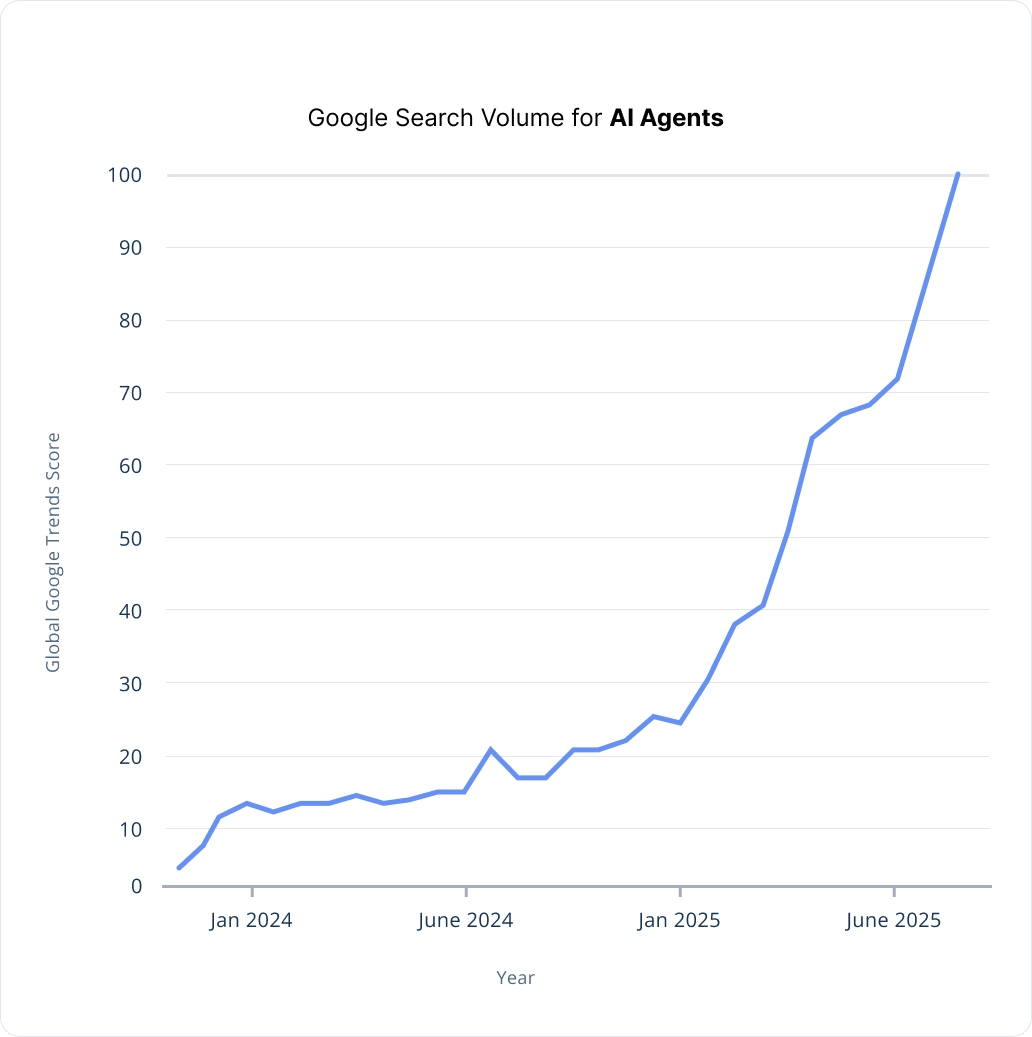

Here's a short demo of **OpenAI's ChatGPT Agent** — under 2 minutes. Watch how it autonomously researches San Francisco budget data across multiple PDFs, extracts hundreds of numbers, and generates a formatted Excel spreadsheet — all from a single prompt.

Pay attention to how it **plans, executes multiple steps, and completes a complex workflow** without being told exactly what to do at each step. That's the agent vs chatbot distinction in action.

Now that you've seen an agent in action, let's build a precise understanding of what makes a system agentic. It helps to think about agents from **three angles**: their **key characteristics**, their **components**, and how they **operate**. Together these give you a complete mental model — and you'll see all three reflected in everything we build. Let's go!

What makes a system agentic? Three defining characteristics:

- **Goal-orientation**: The system is designed to achieve specific objectives — it's task-driven, not just response-driven
- **Autonomy**: It operates independently, making decisions without constant human input
- **Environmental interaction**: It can both perceive its environment (gathering information) and affect it (taking actions)

These aren't abstract — you've already built something that exhibits all three. The Hotel Assistant from the Tool Use course focused on travel-related tasks, independently decided which tools to call, and both gathered information (searching hotels, checking weather) and affected the environment (making bookings).

Would you say your SQL agent idea shares these same characteristics?

Now let's look at what an agent is actually made of. Every agent has four core components:

- **LLM**: The reasoning engine — understands requests and decides what to do next
- **Tools**: Functions that let the agent perceive and act in its environment
- **Memory**: Conversation history and context that inform future decisions
- **Execution Control**: The mechanism that keeps the loop going — or knows when to stop

Your Hotel Assistant from the Tool Use course had all four: an LLM for thinking, tools for searching hotels and making bookings, conversation history as memory, and a while loop that iterated until no more tool calls were needed.

Your SQL agent would follow the same pattern — with tools like list_tables, get_schema, and execute_query in place of the hotel tools.

But before we touch code, one last piece of the conceptual puzzle — **how agents actually operate**. This will make the code click immediately when we get there.

Agents follow a cycle called **ReAct** (Reasoning and Acting):

- Input: Receive the user's task
- Reason: Analyze the situation — what tools are needed?
- Act: Execute those tools
- Observe: Process the results
- Reason again: Are we done, or do we need more actions?
- Repeat until the task is complete

You can see this cycle here — the Reason and Act nodes loop back on each other, with the LLM, Memory, and Tools feeding into that cycle. The loop exits only when the LLM decides the task is done.

This is exactly what your Hotel Assistant was doing with its while loop — just without the formal name. LangGraph will give this pattern a clean, explicit structure.

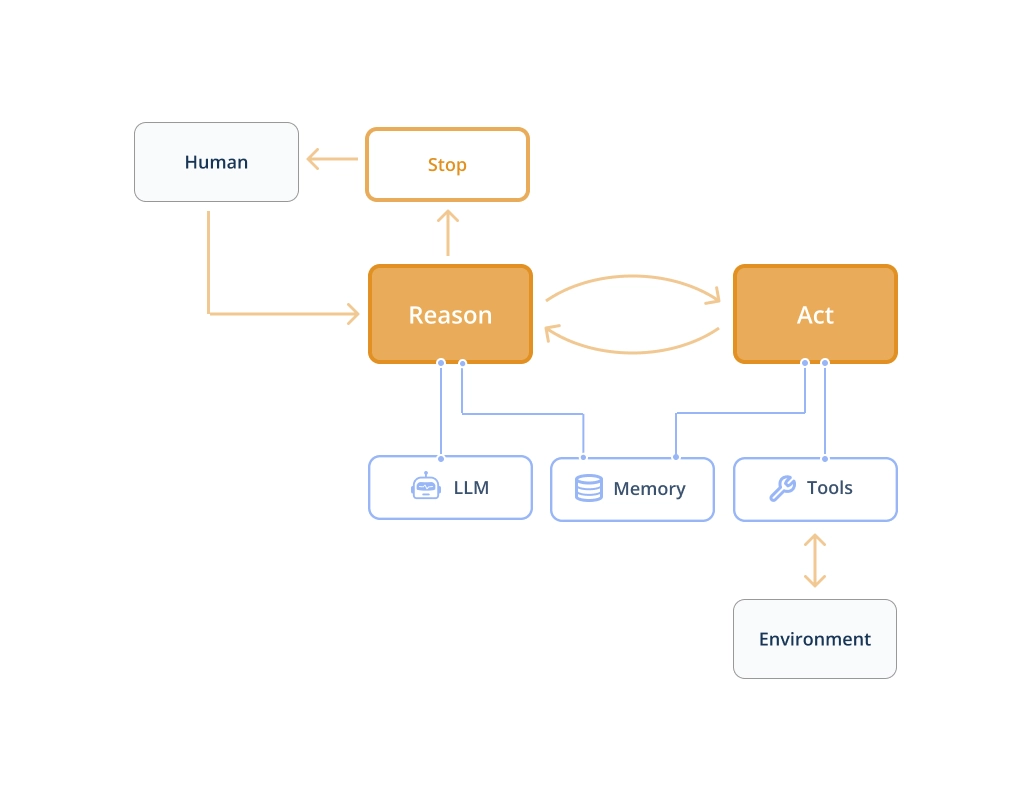

Perfect — now for the framework we'll use to build agentic systems: **LangGraph**.

You've been using **LangChain** throughout this track. For everything we've built so far — chatbots, RAG, tool calling — LangChain is a great fit. But when you move into agentic systems with complex loops, branching logic, and multiple interacting components, LangChain becomes cumbersome.

**LangGraph** was built specifically for this. Created by the same team as LangChain, it gives you:

- A proven framework for structuring agentic systems
- Building blocks to implement virtually any agency-reliability balance
- Cleaner, more maintainable code than rolling your own orchestration logic

Good. Now a natural question: why not just stick with LangChain?

LangChain was built in the **pre-agent era**, optimized for linear workflows — conversation management, RAG, basic tool use. It handles those elegantly, and for your simpler applications it remains the right choice.

But **agentic systems require loops, branching logic, and complex state management** — architectural patterns LangChain wasn't designed for. The code becomes tangled quickly.

**LangGraph** was built specifically to address this. It's worth noting that for chatbots, RAG, and simple tool calling — the kind of work you've done so far — LangGraph would be unnecessary overhead. But for what you're building toward (a SQL agent that chains multiple tools autonomously), it's the right tool.